# Exercise 4.A Introduction to Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1 
### Running a sample script

In [4]:
# Sample dataset: hours studied vs. exam score
data = {
'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
'exam_score': [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)
# Step 1: Define features (X) and target (y)
X = df[['hours_studied']] # 2D: double brackets give a DataFrame
y = df['exam_score'] # 1D: single brackets give a Series
# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [5]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}') 
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [6]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test)) 
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [7]:
r_squared = model.score(X_test, y_test) 
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


Based on the Week 7 Student Guide, R² measures how much of the variation in your target variable is explained by your model. The result was almost at a 1.0 (perfect prediciton) but fell short. So the model explains 99.8%  of the variation and 0.2% remains unexplained.

c:\Users\mruiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


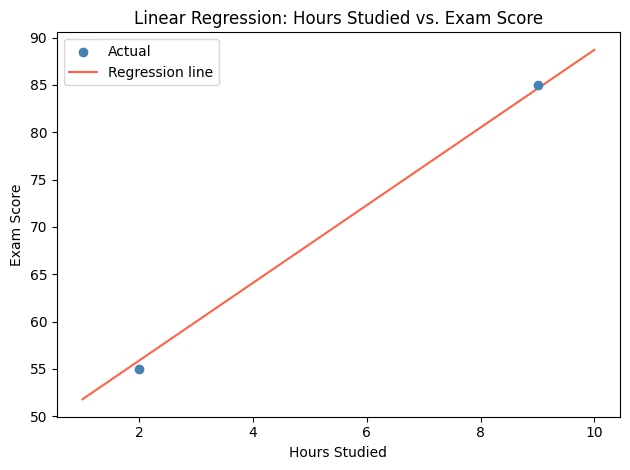

In [8]:
# Scatter plot: actual test data points 
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3) 

# Line: model predictions across the full range of X 
x_range = np.linspace( 
    X['hours_studied'].min(), 
    X['hours_studied'].max(), 100).reshape(-1, 1) 
y_line = model.predict(x_range) 
plt.plot(x_range, y_line, color='tomato', label='Regression line') 
plt.xlabel('Hours Studied') 
plt.ylabel('Exam Score') 
plt.title('Linear Regression: Hours Studied vs. Exam Score') 
plt.legend() 
plt.tight_layout()
plt.show()

The cata points are so close to touchig the regression line. The top point slightly touches the line while the bottom point is just decimals away from mdoing so. It just shows a nearly perfect regression between both variables.

## Lab 2 
### Building your own model

In [9]:
ad_data = { 
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000], 
                         'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 
                                             12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 
                                             23800]}

In [13]:
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [15]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X2,y2, test_size=0.2, random_state=42)

In [16]:
model2 = LinearRegression()
model2.fit(X_train, y_train)
print('Model trained successfully.')

Model trained successfully.


In [18]:
print(f'Slope: {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}') #For each additional $1 that is spent monthly on ads, the predicted monthly revenue increases by $1.96.

Slope: 1.96
Intercept: 3625.89


### Making predictions and evaluating the model.

In [24]:
#y_pred = model.predict(X_test)
#print(f'Actual Revenue {y_test.values}')
#print(f'Predicted Revenue {y_pred.round(2)}')

y_pred = model2.predict(X_test)
print(f'Actual Revenue {y_test.values}')
print(f'Predicted Revenue {y_pred.round(2)}')

Actual Revenue [ 4200 21500 19400  5100]
Predicted Revenue [ 4603.85 21229.03 19273.13  5581.8 ]


In [28]:
r2_squared = model2.score(X_test, y_test) 
print(f'R² score: {r2_squared:.3f}')

R² score: 0.998


99.8% of the variation is explained by the ad spend which is a nearly perfect prediction (1.0).

### Visualizing the results.

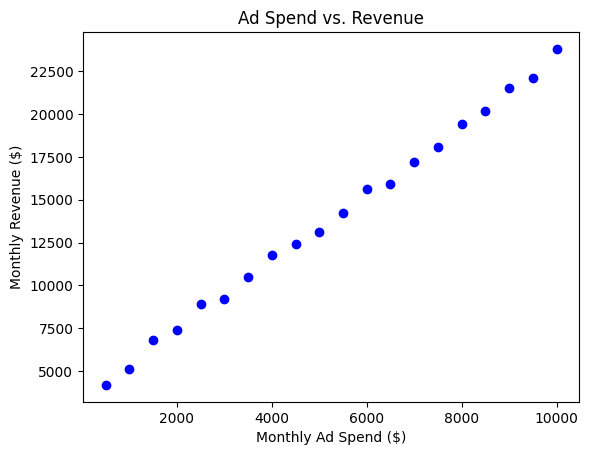

In [29]:
plt.scatter(X2, y2, color='blue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.show()

c:\Users\mruiz\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


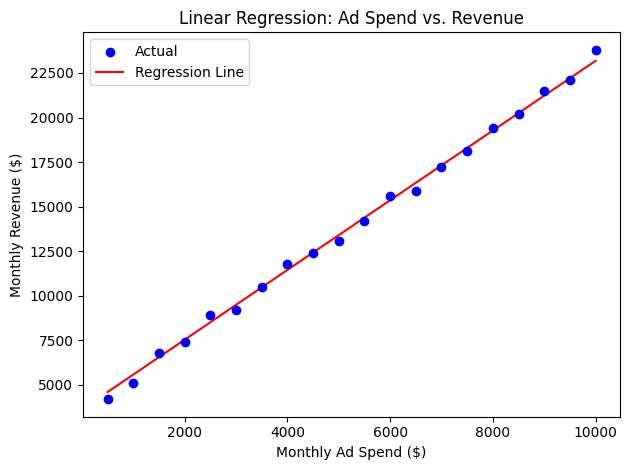

In [32]:
plt.scatter(X2, y2, color='blue', label='Actual', zorder=3)
x_range = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100).reshape(-1, 1)

y_line = model2.predict(x_range)

plt.plot(x_range, y_line, color='red', label='Regression Line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Linear Regression: Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

This regression line fits the data as close as it possibly could. Many points are ON the line and those that are not are SO close to touching it. 